# Revision analyses for manuscript 1936750 (Frontiers in Immunology)

Supplementary analyses requested at peer review. This notebook re-derives the analysis sample exactly as in `immunogenetic_grandiosity_analysis_v2.ipynb` (same functions, same seed) and then adds the analyses requested by the reviewers. Every number quoted in the revised manuscript or the reply to reviewers that is not in the main notebook is written to `revision_manifest.json` at the end.

Contents: S1 marker-level quality control and case-control allele frequencies; S2 within-gene linkage disequilibrium; S3 SKAT kernel and weighting sensitivity; S4 grandiosity score distribution and genotype-by-score counts; S5 continuous-outcome recessive estimate and fragility of the two-copy effect; S6 genotype principal components as a crude stratification check; S7 OPCRIT rating period and neuroleptic-response sensitivity; S8 case-control comparison of the IL10 -819/-592 locus; S9 unsupervised anomaly detection with the autoencoder architecture reported and a bottleneck sensitivity; S10 manifest.

## 0. Configuration, embedded methods, and data derivation (identical to the main notebook)

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import statsmodels.api as sm
from collections import Counter
from scipy import stats, optimize
from scipy.integrate import quad
from scipy.stats import gaussian_kde, ncx2
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve, auc
from matplotlib import gridspec
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, Normalize
from matplotlib.cm import ScalarMappable

# reproducibility
MASTER_SEED = 20260704
np.random.seed(MASTER_SEED)

# data paths: edit to point to your copies of the two files
GENO_PATH   = "interleukiny_genotypy.xlsx"
OPCRIT_PATH = "opcrit_baza.xlsx"
GENO_KEY, OPCRIT_KEY, VNTR_COL = "Nowy numer kodu", "nowy_nr_kodu", "Il1RA (86bp) -Genotypy"
DISEASE_COL = "Choroba"   # genotype file: 0 = control, 4 = schizophrenia

# permutation and resampling budgets (raise for a final run)
N_PERM_SEL, N_SPLIT_HONEST, N_PERM_AMP, N_SPLIT = 3000, 500, 200, 100

# publication palette (grey for data and nulls, coral for the located signal)
CORAL, GREY, DGREY = "#EA5B5D", "#8D8D8D", "#484d54"
sns.set_style("white")
plt.rcParams.update({"axes.grid": False, "figure.dpi": 120, "axes.edgecolor": "#333",
                     "font.size": 10.5, "axes.titlesize": 11, "axes.titleweight": "bold",
                     "legend.frameon": False, "savefig.bbox": "tight"})
CORALS = LinearSegmentedColormap.from_list("c", ["#e2e5e9","#f0a58f",CORAL,"#a5140f"])
PURPCM = LinearSegmentedColormap.from_list("p", ["#f4eff8","#c9b8e6","#8b6fc4","#3f1a70"])
TGP    = LinearSegmentedColormap.from_list("tgp",["#1f7a63","#5DBFA9","#bfe3d8","#ece9e3","#ece9e3","#c9b8e6","#8b6fc4","#3f1a70"])
GREYCM = LinearSegmentedColormap.from_list("g", ["#c4c9cf","#9198a0","#484d54"])

# ---- figure export: journal specification ----
# Frontiers wants 300 dpi at final size, RGB, and no text smaller than 8 pt.
# Every figure is therefore drawn at its final width and saved as an LZW TIFF.
FIG_RC = {"font.size": 8, "axes.titlesize": 9.5, "axes.labelsize": 8.5,
          "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
          "axes.titlepad": 13.0, "figure.dpi": 300, "savefig.dpi": 600,
          "font.family": "DejaVu Sans"}

def save_tiff(fig, path, dpi=300):
    """Save as an RGB, LZW-compressed TIFF at the given dpi."""
    from PIL import Image
    fig.savefig(path, dpi=dpi, bbox_inches="tight",
                pil_kwargs={"compression": "tiff_lzw"})
    im = Image.open(path)
    if im.mode != "RGB":
        bg = Image.new("RGB", im.size, (255, 255, 255))
        bg.paste(im, mask=im.split()[-1] if im.mode == "RGBA" else None)
        im = bg
    im.save(path, compression="tiff_lzw", dpi=(dpi, dpi))


In [2]:
# ---- rank inverse-normal transform (Blom) ----
def rint(x):
    x = np.asarray(x, float); ranks = stats.rankdata(x)
    return stats.norm.ppf((ranks - 0.5) / len(x))

# ---- SKAT: exact Davies p-value (used for observed statistics) ----
def davies_pvalue(q, lam):
    lam = np.asarray(lam, float); lam = lam[np.abs(lam) > 1e-10]
    if len(lam) == 0: return 1.0
    def integrand(u):
        theta = 0.5*np.sum(np.arctan(lam*u)) - 0.5*q*u
        rho = np.prod((1.0 + (lam*u)**2)**0.25)
        return np.sin(theta)/(u*rho)
    val, _ = quad(integrand, 0, np.inf, limit=200, epsabs=1e-8, epsrel=1e-8)
    return float(min(max(0.5 + val/np.pi, 1e-12), 1.0))

# ---- SKAT: Liu 2009 four-moment chi-square approximation (fast, used in permutations) ----
def liu_pvalue(q, lam):
    lam = np.asarray(lam, float); lam = lam[np.abs(lam) > 1e-10]
    if len(lam) == 0: return 1.0
    c = np.array([lam.sum(), (lam**2).sum(), (lam**3).sum(), (lam**4).sum()])
    muQ = c[0]; sigmaQ = np.sqrt(2*c[1]); s1 = c[2]/c[1]**1.5; s2 = c[3]/c[1]**2
    if s1**2 > s2:
        a = 1/(s1 - np.sqrt(s1**2 - s2)); d = s1*a**3 - a**2; l = a**2 - 2*d
    else:
        a = 1/s1; d = 0.0; l = 1/s2
    muX = l + d; sigmaX = np.sqrt(2)*a
    Qn = (q - muQ)/sigmaQ*sigmaX + muX
    return float(ncx2.sf(Qn, df=l, nc=d))

def skat_eigen(G, X):
    # nonzero-eigenvalue structure of the residualised genotype Gram matrix; depends only on G and X
    XtXinv = np.linalg.inv(X.T @ X); GtX = G.T @ X
    M = G.T @ G - GtX @ XtXinv @ GtX.T
    return np.clip(np.linalg.eigvalsh(M), 0, None)

def skat_test(G, y, X, method="davies"):
    n, p = X.shape
    beta, *_ = np.linalg.lstsq(X, y, rcond=None); r = y - X @ beta
    sigma2 = (r @ r) / (n - p); s = G.T @ r; Q = (s @ s) / sigma2
    lam = skat_eigen(G, X)
    return (davies_pvalue(Q, lam) if method == "davies" else liu_pvalue(Q, lam)), Q

# ---- additive genotype encoding (minor-allele dosage; IL1RN VNTR short-repeat count) ----
def _alleles(series):
    v = series.dropna().astype(str); v = v[v.str.len() == 2]
    cnt = Counter("".join(v.tolist())); return sorted(cnt.keys()), cnt

def dosage_minor(series):
    al, cnt = _alleles(series)
    if len(al) < 2: return pd.Series(np.nan, index=series.index), None
    minor = min(al, key=lambda a: cnt[a])
    f = lambda v: (str(v).count(minor) if (isinstance(v, str) and len(str(v)) == 2) else np.nan)
    return series.map(f), minor

def vntr_short2(series):
    def f(v):
        if pd.isna(v): return np.nan
        s = str(int(v)) if isinstance(v, float) else str(v); return s.count("2")
    return series.map(f)

# ---- Hardy-Weinberg exact-style chi-square test and call rate ----
def hwe_callrate(series):
    v = series.dropna().astype(str); v = v[v.str.len() == 2]; call = len(v)
    al, _ = _alleles(series)
    if len(al) < 2 or call == 0: return call, np.nan, np.nan
    a1, a2 = al; n = call
    naa = (v.map(lambda g: "".join(sorted(g)) == a1+a1)).sum()
    nbb = (v.map(lambda g: "".join(sorted(g)) == a2+a2)).sum()
    nab = n - naa - nbb
    p = (2*naa + nab)/(2*n); q = 1-p
    e = [n*p*p, 2*n*p*q, n*q*q]; o = [naa, nab, nbb]
    chi = sum((oi-ei)**2/ei for oi, ei in zip(o, e) if ei > 0)
    return call, float(stats.chi2.sf(chi, 1)), float(p)

# ---- Benjamini-Hochberg FDR ----
def bh_fdr(pvals):
    p = np.asarray(pvals, float); m = len(p); order = np.argsort(p)
    q = np.empty(m); prev = 1.0
    for i in range(m-1, -1, -1):
        rank = i + 1; val = p[order[i]] * m / rank; prev = min(prev, val); q[order[i]] = prev
    return np.clip(q, 0, 1)

# ---- Firth penalized logistic regression with profile-likelihood CI (Firth 1993; Heinze and Schemper 2002) ----
def _firth_fit(X, y, tol=1e-8, maxit=200):
    n, p = X.shape; beta = np.zeros(p)
    for _ in range(maxit):
        pi = 1/(1+np.exp(-(X@beta))); W = pi*(1-pi); Wr = np.sqrt(W)
        XtWX = X.T @ (W[:,None]*X)
        try: inv = np.linalg.inv(XtWX)
        except np.linalg.LinAlgError: inv = np.linalg.pinv(XtWX)
        H = (Wr[:,None]*X) @ inv @ (Wr[:,None]*X).T; h = np.clip(np.diag(H), 0, None)
        step = inv @ (X.T @ (y - pi + h*(0.5 - pi))); beta = beta + step
        if np.max(np.abs(step)) < tol: break
    return beta, inv

def _pen_loglik(X, y, beta):
    pi = 1/(1+np.exp(-(X@beta))); W = pi*(1-pi)
    _, logdet = np.linalg.slogdet(X.T @ (W[:,None]*X))
    ll = np.sum(y*np.log(np.clip(pi,1e-12,1)) + (1-y)*np.log(np.clip(1-pi,1e-12,1)))
    return ll + 0.5*logdet

def _firth_profile_ll(X, y, coef, b_fixed):
    mask = np.ones(X.shape[1], bool); mask[coef] = False
    Xr = X[:, mask]; off = X[:, coef]*b_fixed; bb = np.zeros(Xr.shape[1])
    for _ in range(200):
        pi = 1/(1+np.exp(-(Xr@bb + off))); W = pi*(1-pi); Wr = np.sqrt(W)
        XtWX = Xr.T @ (W[:,None]*Xr)
        try: inv = np.linalg.inv(XtWX)
        except np.linalg.LinAlgError: inv = np.linalg.pinv(XtWX)
        H = (Wr[:,None]*Xr) @ inv @ (Wr[:,None]*Xr).T; h = np.clip(np.diag(H), 0, None)
        step = inv @ (Xr.T @ (y - pi + h*(0.5 - pi))); bb = bb + step
        if np.max(np.abs(step)) < 1e-9: break
    full = np.zeros(X.shape[1]); full[mask] = bb; full[coef] = b_fixed
    return _pen_loglik(X, y, full)

def firth_logit(X, y, coef=1):
    beta, cov = _firth_fit(X, y); ll_full = _pen_loglik(X, y, beta)
    crit = stats.chi2.ppf(0.95, 1)/2
    def g(b): return ll_full - _firth_profile_ll(X, y, coef, b) - crit
    bhat = beta[coef]; se = np.sqrt(cov[coef, coef])
    lo = optimize.brentq(g, bhat-10*se-1, bhat) if g(bhat-10*se-1) > 0 else optimize.brentq(g, bhat-40, bhat)
    hi = optimize.brentq(g, bhat, bhat+10*se+1) if g(bhat+10*se+1) > 0 else optimize.brentq(g, bhat, bhat+40)
    lr = 2*(ll_full - _firth_profile_ll(X, y, coef, 0.0)); pval = stats.chi2.sf(lr, 1)
    return bhat, np.exp(bhat), (np.exp(lo), np.exp(hi)), pval

def opcrit_item_map(o):
    m = {}
    for c in o.columns:
        s = str(c).strip(); num = ""
        for ch in s:
            if ch.isdigit(): num += ch
            else: break
        if num: m.setdefault(int(num), c)
    return m


In [3]:
# ---- source data ----
# The two source files hold individual-level clinical and genotype data and are
# not distributed with this repository. Place your copies beside the notebooks,
# or edit the two paths above. Their SHA-256 digests are in inputs.sha256, so a
# holder of the data can confirm the files are the ones used here.
import os
_missing = [p for p in (GENO_PATH, OPCRIT_PATH) if not os.path.exists(p)]
if _missing:
    raise FileNotFoundError(
        "Source data not found: " + ", ".join(_missing) + ". "
        "These files are not part of the repository. Requests to access them should be "
        "directed to the corresponding author; see the Data Availability Statement.")

geno_all = pd.read_excel(GENO_PATH).rename(columns={GENO_KEY: "code"})
opc      = pd.read_excel(OPCRIT_PATH).rename(columns={OPCRIT_KEY: "code"})
geno_all["code"] = geno_all["code"].astype(str); opc["code"] = opc["code"].astype(str)
geno = geno_all.copy()
merged = opc.merge(geno, on="code", how="inner"); N_LINK = len(merged)
imap = opcrit_item_map(opc)
def item(it): return pd.to_numeric(merged[imap[it]].replace("BD", np.nan), errors="coerce")

# genotype dosage frame grouped by gene
snp_cols = [c for c in geno.columns if str(c).startswith("rs")]
dos_raw = pd.DataFrame({c.split("_")[0]: dosage_minor(merged[c])[0] for c in snp_cols}, index=merged.index)
dos_raw["VNTR"] = vntr_short2(merged[VNTR_COL])
dosk = dos_raw.apply(lambda s: s.fillna(s.mean()))   # mean imputation for the in-sample SKAT screen only
GENES = {"IL1A":["rs1800587","rs17561"],
         "IL1B":["rs1143643","rs16944","rs1143623","rs1143633","rs1143627"],
         "IL1RN":["VNTR","rs419598","rs315952","rs9005","rs4251961"],
         "IL6":["rs1800797","rs1800795"],
         "IL6R":["rs2228145","rs4537545","rs4845617"],
         "IL10":["rs1800871","rs1800872","rs1800896","rs1800890","rs6676671"],
         "IL10RA":["rs2229113","rs3135932"],
         "TGFB1":["rs1800469","rs1800470"]}
GENE_ORDER = list(GENES.keys())
markers = [m for gn in GENE_ORDER for m in GENES[gn] if m in dosk.columns]
IL10 = [m for m in GENES["IL10"] if m in dosk]

# grandiosity phenotype: OPCRIT item 56 (inflated self-esteem) + item 57 (grandiose delusions), each 0-2, sum 0-4.
# Missing items are left missing rather than treated as absent; patients without both items are dropped from outcome analyses.
it56, it57 = item(56), item(57)
grand = (it56 + it57).values                       # NaN if either item missing
valid = ~np.isnan(grand)                            # analysis mask for the grandiosity outcome
N = int(valid.sum())                               # analysis N for association work

# IL-10 -819/-592 dose from the two tag SNPs (rs1800871, rs1800872). These are in near-complete LD, so their
# summed minor-allele dosage recovers 0/1/2 copies of the shared -819/-592 haplotype. The direction is taken
# empirically from this sample and is not asserted to be the functional low-producer allele (see section 7).
load   = (dos_raw["rs1800871"] + dos_raw["rs1800872"])
copies = np.where(load <= 0, 0, np.where(load >= 3, 2, 1)).astype(float)
copies[load.isna().values] = np.nan

# covariates: sex (item 3), age (Wiek), age at onset (item 4); median fill, standardised
covdf = pd.DataFrame({"sex": item(3).values, "age": pd.to_numeric(merged["Wiek"], errors="coerce").values, "onset": item(4).values})
covdf = covdf.apply(lambda s: s.fillna(s.median()))
Xcov_full = np.column_stack([np.ones(N_LINK), ((covdf - covdf.mean())/covdf.std()).values])

# symptom dimensions (mean of item scores) for the specificity analysis
def dim(items):
    d = pd.DataFrame({f"it{i}": item(i) for i in items}); s = d.mean(axis=1, skipna=True); return s.fillna(s.mean()).values
DIMS = {"grandiosity": grand,
        "mania": dim([20,21,22,23,30,31,35,36,53]), "depressive": dim([37,39,41,42,43]),
        "negative": dim([24,25,32,33,39,40]), "delusions": dim([54,55,58,59,60,61]),
        "hallucinations": dim([73,74,75,76,77])}

ld = np.corrcoef(dos_raw["rs1800871"].dropna().align(dos_raw["rs1800872"].dropna(), join="inner")[0],
                 dos_raw["rs1800871"].dropna().align(dos_raw["rs1800872"].dropna(), join="inner")[1])[0,1]
print(f"Linked cohort: {N_LINK} patients with genotype and OPCRIT")
print(f"Grandiosity observable in {N} of {N_LINK} (analysis N = {N}; {N_LINK-N} dropped for missing item 56 or 57)")
print(f"{len(markers)} interleukin markers across {len(GENES)} genes")
print(f"rs1800871 and rs1800872 dosage correlation r = {ld:.3f} (near-complete LD: effectively one locus)")

# ---- integrity checks on the derived analysis set ----
# If any of these fail, the data in the working directory are not the cohort the
# published results were computed from, and nothing below should be trusted.
assert N_LINK == 490, f"expected 490 linked patients, found {N_LINK}"
assert N == 489, f"expected an analysis sample of 489, found {N}"
assert len(markers) == 26, f"expected 26 markers, found {len(markers)}"
assert len(GENES) == 8, f"expected 8 genes, found {len(GENES)}"
assert int(np.nansum(grand[valid] > 0)) == 133, "grandiosity prevalence does not match the published sample"
n_dosage_cells = int(np.asarray(dos_raw[markers].values[valid]).size)
n_imputed = int(np.isnan(np.asarray(dos_raw[markers].values[valid], float)).sum())
pct_imputed = 100.0 * n_imputed / n_dosage_cells
assert n_imputed == 169, f"expected 169 imputed dosage cells, found {n_imputed}"
print(f"Missing dosages mean-imputed once across the analysis sample: "
      f"{n_imputed} of {n_dosage_cells} cells ({pct_imputed:.2f}%).")
print("Integrity checks passed: 490 linked, 489 analysed, 26 markers across 8 genes, 133 with grandiosity.")


Linked cohort: 490 patients with genotype and OPCRIT
Grandiosity observable in 489 of 490 (analysis N = 489; 1 dropped for missing item 56 or 57)
26 interleukin markers across 8 genes
rs1800871 and rs1800872 dosage correlation r = 0.994 (near-complete LD: effectively one locus)
Missing dosages mean-imputed once across the analysis sample: 169 of 12714 cells (1.33%).
Integrity checks passed: 490 linked, 489 analysed, 26 markers across 8 genes, 133 with grandiosity.


In [4]:
# analysis-sample objects shared by the sections below
yv = valid; gy = rint(grand[yv]); Xcov = Xcov_full[yv]
cp = copies[valid]; gb = (grand[valid] > 0).astype(float); gc = grand[valid]
m2 = ~np.isnan(cp); cpi = cp[m2].astype(int); gbi = gb[m2]; gci = gc[m2]
Zc = ((covdf - covdf.mean())/covdf.std()).values[valid][m2]
MANIFEST = {}
def put(k, v, dec=None):
    MANIFEST[k] = {"value": (float(v) if isinstance(v,(int,float,np.floating,np.integer)) else v), "decimals": dec}
print("analysis N =", N, "| IL-10 genotype available in", int(m2.sum()))

analysis N = 489 | IL-10 genotype available in 454


## S1. Marker-level quality control and case-control allele frequencies (Supplementary Table S1)

For each of the 25 SNPs: counted (minor) allele, call rate in cases, minor-allele frequency in cases and in the 521 genotype-only controls, Hardy-Weinberg p in each group, and an allelic case-control chi-square test with Benjamini-Hochberg control across the 25 SNPs. The IL1RN repeat is summarised separately.

In [5]:
ctrl = geno_all[geno_all[DISEASE_COL] == 0]; cases = geno_all[geno_all[DISEASE_COL] == 4]
snp_col_of = {c.split("_")[0]: c for c in snp_cols}
gene_of = {m: gn for gn, ms in GENES.items() for m in ms}
POS = {"rs1800896":"-1082","rs1800871":"-819","rs1800872":"-592","rs16944":"-511","rs1800795":"-174","rs1800797":"-597","rs1800469":"-509","rs1800587":"-889","rs1800470":"+869 (Leu10Pro)","rs2228145":"Asp358Ala","rs1143627":"-31","rs1800890":"-3575"}
def allele_counts(series, minor):
    v = series.dropna().astype(str); v = v[v.str.len()==2]
    return sum(s.count(minor) for s in v), 2*len(v)
rows = []
for m in markers:
    if m == "VNTR": continue
    col = snp_col_of[m]; _, minor = dosage_minor(merged[col])
    call_c, hwe_c, _ = hwe_callrate(merged[col]); call_k, hwe_k, _ = hwe_callrate(ctrl[col])
    a_c, n_c = allele_counts(merged[col], minor); a_k, n_k = allele_counts(ctrl[col], minor)
    tab = np.array([[a_c, n_c-a_c],[a_k, n_k-a_k]]); chi, p_cc, _, _ = stats.chi2_contingency(tab, correction=False)
    or_cc = (a_c*(n_k-a_k))/((n_c-a_c)*a_k)
    rows.append({"gene": gene_of[m], "SNP": m, "position": POS.get(m,""), "counted allele": minor,
                 "call rate, cases": f"{call_c}/{N_LINK} ({100*call_c/N_LINK:.1f}%)",
                 "MAF cases": round(a_c/n_c,3), "MAF controls": round(a_k/n_k,3),
                 "HWE p cases": round(hwe_c,3), "HWE p controls": round(hwe_k,3),
                 "allelic OR (case vs control)": round(or_cc,2), "allelic p": p_cc})
S1 = pd.DataFrame(rows); S1["allelic q (BH, 25 SNPs)"] = bh_fdr(S1["allelic p"].values).round(3); S1["allelic p"] = S1["allelic p"].round(4)
S1.to_csv("Supplementary_Table_S1_markers.csv", index=False)
print(S1.to_string(index=False))
vn = merged[VNTR_COL]; print(f"\nIL1RN 86 bp VNTR: called in {vn.notna().sum()}/{N_LINK} cases; encoded as short-repeat (allele 2) count")
put("S1_min_call_rate_pct", 100*min(int(r["call rate, cases"].split("/")[0]) for r in rows)/N_LINK, 1)
put("S1_n_hwe_fail_cases", int((S1["HWE p cases"] < 0.05).sum())); put("S1_n_hwe_fail_controls", int((S1["HWE p controls"] < 0.05).sum()))
put("S1_min_allelic_q", float(S1["allelic q (BH, 25 SNPs)"].min()), 3)
for rs in ["rs1800871","rs1800872"]:
    r = S1[S1.SNP==rs].iloc[0]; put(f"S1_{rs}_MAF_cases", r["MAF cases"], 3); put(f"S1_{rs}_MAF_controls", r["MAF controls"], 3); put(f"S1_{rs}_HWE_cases", r["HWE p cases"], 3); put(f"S1_{rs}_HWE_controls", r["HWE p controls"], 3); put(f"S1_{rs}_allelic_p", r["allelic p"], 4)

  gene       SNP        position counted allele call rate, cases  MAF cases  MAF controls  HWE p cases  HWE p controls  allelic OR (case vs control)  allelic p  allelic q (BH, 25 SNPs)
  IL1A rs1800587            -889              A  484/490 (98.8%)      0.284         0.294        0.665           0.249                          0.95     0.6193                    0.910
  IL1A   rs17561                              A  481/490 (98.2%)      0.282         0.292        0.852           0.175                          0.95     0.6125                    0.910
  IL1B rs1143643                              T  488/490 (99.6%)      0.388         0.385        0.148           0.886                          1.01     0.8734                    0.910
  IL1B   rs16944            -511              A  488/490 (99.6%)      0.339         0.334        0.404           0.291                          1.02     0.8187                    0.910
  IL1B rs1143623                              G  488/490 (99.6%)      0.291

## S2. Within-gene linkage disequilibrium (Supplementary Table S2)

Pairwise r² between the dosage vectors of every pair of markers within a gene set, in the analysis sample (pairwise-complete). r² above 0.8 is flagged and used to define the LD-pruned sensitivity analysis in S3.

In [6]:
ld_rows = []
for gn, ms in GENES.items():
    ms = [m for m in ms if m in dos_raw]
    for i in range(len(ms)):
        for j in range(i+1, len(ms)):
            a, b = dos_raw[ms[i]], dos_raw[ms[j]]; ok = a.notna() & b.notna()
            r2 = np.corrcoef(a[ok], b[ok])[0,1]**2
            ld_rows.append({"gene": gn, "marker 1": ms[i], "marker 2": ms[j], "n": int(ok.sum()), "r2": round(r2,3), "flag (r2 > 0.8)": "yes" if r2 > 0.8 else ""})
S2 = pd.DataFrame(ld_rows); S2.to_csv("Supplementary_Table_S2_LD.csv", index=False); print(S2.to_string(index=False))
high = S2[S2["r2"] > 0.8]; print("\nPairs with r2 > 0.8:", high[["gene","marker 1","marker 2","r2"]].values.tolist())
put("S2_n_pairs_r2_over_0.8", int(len(high))); put("S2_max_r2_nonIL10", float(S2[S2.gene!="IL10"]["r2"].max()), 3)
put("S2_TGFB1_r2", float(S2[S2.gene=="TGFB1"]["r2"].iloc[0]), 3)
put("S2_IL10_tags_r2", float(S2[(S2["marker 1"]=="rs1800871")&(S2["marker 2"]=="rs1800872")]["r2"].iloc[0]), 3)

  gene  marker 1  marker 2   n    r2 flag (r2 > 0.8)
  IL1A rs1800587   rs17561 475 1.000             yes
  IL1B rs1143643   rs16944 486 0.186                
  IL1B rs1143643 rs1143623 486 0.140                
  IL1B rs1143643 rs1143633 480 0.977             yes
  IL1B rs1143643 rs1143627 485 0.183                
  IL1B   rs16944 rs1143623 486 0.771                
  IL1B   rs16944 rs1143633 480 0.180                
  IL1B   rs16944 rs1143627 485 0.981             yes
  IL1B rs1143623 rs1143633 480 0.142                
  IL1B rs1143623 rs1143627 485 0.784                
  IL1B rs1143633 rs1143627 479 0.177                
 IL1RN      VNTR  rs419598 477 0.849             yes
 IL1RN      VNTR  rs315952 482 0.067                
 IL1RN      VNTR    rs9005 478 0.502                
 IL1RN      VNTR rs4251961 476 0.186                
 IL1RN  rs419598  rs315952 481 0.071                
 IL1RN  rs419598    rs9005 479 0.559                
 IL1RN  rs419598 rs4251961 477 0.209          

## S3. SKAT kernel and weighting sensitivity

The main analysis used a linear kernel with unweighted minor-allele dosages (all variant weights equal), which is the appropriate default for a panel of common functional variants. Three alternatives are run over the same eight gene sets: (i) the original unweighted linear kernel; (ii) the Wu et al. (2011) default Beta(1,25) minor-allele-frequency weights, which up-weight rarer variants; (iii) the unweighted linear kernel on an LD-pruned panel in which the second member of every within-gene pair with r² above 0.8 is dropped; (iv) a linear kernel with each gene's markers standardised to unit variance, which removes any dependence on allele frequency. Each variant reports the eight per-gene p values and BH q values.

In [7]:
def skat_variant(kind):
    out = {}
    for gn, ms in GENES.items():
        ms = [m for m in ms if m in dosk]
        if kind == "pruned":
            drop = set(high[high.gene==gn]["marker 2"]); ms = [m for m in ms if m not in drop]
        G = dosk[ms].values[yv].astype(float)
        if kind == "beta":
            maf = np.array([np.nanmean(dos_raw[m].values[yv])/2 if m!="VNTR" else np.nanmean(dos_raw[m].values[yv])/2 for m in ms])
            maf = np.clip(np.minimum(maf, 1-maf), 1e-3, 0.5); w = stats.beta.pdf(maf, 1, 25); w = w / w.max(); G = G * w   # weights rescaled to max 1 for numerical stability; the test is scale-invariant
        if kind == "standardised":
            G = (G - G.mean(0)) / G.std(0)
        out[gn] = skat_test(G, gy, Xcov, "davies")[0]
    return out
S3 = {}
for kind, lab in [("linear","unweighted linear (main)"),("beta","Beta(1,25) MAF-weighted"),("pruned","LD-pruned (r2 > 0.8), unweighted"),("standardised","standardised dosages")]:
    p = skat_variant(kind); q = dict(zip(p, bh_fdr(list(p.values())))); S3[lab] = {"p": p, "q": q}
tab = pd.DataFrame({lab: {gn: f"{S3[lab]['p'][gn]:.4f} (q {S3[lab]['q'][gn]:.3f})" for gn in GENE_ORDER} for lab in S3})
tab.to_csv("Supplementary_Table_S3_SKAT_sensitivity.csv"); print(tab.to_string())
for lab in S3:
    key = {"unweighted linear (main)":"unweighted","Beta(1,25) MAF-weighted":"beta125","LD-pruned (r2 > 0.8), unweighted":"pruned","standardised dosages":"standardised"}[lab]
    put(f"S3_IL10_p_{key}", S3[lab]["p"]["IL10"], 4); put(f"S3_IL10_q_{key}", S3[lab]["q"]["IL10"], 3)
    put(f"S3_only_IL10_survives_{key}", bool(all((S3[lab]["q"][g] < 0.05) == (g=="IL10") for g in GENE_ORDER)))

       unweighted linear (main) Beta(1,25) MAF-weighted LD-pruned (r2 > 0.8), unweighted standardised dosages
IL1A           0.6108 (q 0.814)        0.6120 (q 0.721)                 0.5908 (q 0.847)     0.6110 (q 0.815)
IL1B           0.4948 (q 0.814)        0.2874 (q 0.702)                 0.5042 (q 0.847)     0.4910 (q 0.815)
IL1RN          0.5444 (q 0.814)        0.3509 (q 0.702)                 0.6256 (q 0.847)     0.5394 (q 0.815)
IL6            0.8142 (q 0.814)        0.8651 (q 0.865)                 0.9687 (q 0.969)     0.8146 (q 0.815)
IL6R           0.5953 (q 0.814)        0.5857 (q 0.721)                 0.6355 (q 0.847)     0.5963 (q 0.815)
IL10           0.0028 (q 0.023)        0.0003 (q 0.002)                 0.0052 (q 0.042)     0.0012 (q 0.010)
IL10RA         0.4375 (q 0.814)        0.2130 (q 0.702)                 0.4375 (q 0.847)     0.3910 (q 0.815)
TGFB1          0.8109 (q 0.814)        0.6305 (q 0.721)                 0.8109 (q 0.927)     0.8080 (q 0.815)


## S4. Distribution of the grandiosity score (Supplementary Table S4) and genotype-by-score counts (Supplementary Table S5)

The composite score 0 to 4, the cross-tabulation of the two constituent items, and the full 3-by-5 table of IL10 -819/-592 copy number against score. The last of these is the aggregate that can be shared without any individual-level data.

In [8]:
g = grand[valid]
S4 = pd.DataFrame({"grandiosity score": [0,1,2,3,4], "n": [int((g==L).sum()) for L in range(5)]}); S4["%"] = (100*S4["n"]/N).round(1)
print(S4.to_string(index=False)); S4.to_csv("Supplementary_Table_S4_score_distribution.csv", index=False)
xt = pd.crosstab(it56[valid].astype(int), it57[valid].astype(int)); xt.index.name = "item 56 (inflated self-esteem)"; xt.columns.name = "item 57 (grandiose delusions)"
print("\nItem 56 by item 57:\n", xt)
S5 = pd.crosstab(pd.Series(cpi, name="IL10 -819/-592 copies"), pd.Series(gci.astype(int), name="grandiosity score"))
S5["any grandiosity, n (%)"] = [f"{int((gci[cpi==c]>0).sum())} ({100*(gci[cpi==c]>0).mean():.0f})" for c in S5.index]
S5["mean score"] = [round(gci[cpi==c].mean(),2) for c in S5.index]; S5["n"] = [int((cpi==c).sum()) for c in S5.index]
print("\nGenotype by score:\n", S5.to_string()); S5.to_csv("Supplementary_Table_S5_genotype_by_score.csv")
for L in range(5): put(f"S4_n_score_{L}", int((g==L).sum())); put(f"S4_pct_score_{L}", 100*(g==L).mean(), 1)
put("S4_pct_any", 100*(g>0).mean(), 1); put("S4_pct_max", 100*(g==4).mean(), 1)
put("S4_n_item57_positive", int((it57[valid]>0).sum())); put("S4_pct_item57_positive", 100*(it57[valid]>0).mean(), 1)
put("S4_n_item56_positive", int((it56[valid]>0).sum())); put("S4_pct_item56_positive", 100*(it56[valid]>0).mean(), 1)
put("S5_n_two_copy_grandiose", int((gci[cpi==2]>0).sum())); put("S5_n_two_copy", int((cpi==2).sum()))

 grandiosity score   n    %
                 0 356 72.8
                 1  18  3.7
                 2  56 11.5
                 3   8  1.6
                 4  51 10.4

Item 56 by item 57:
 item 57 (grandiose delusions)     0   1   2
item 56 (inflated self-esteem)             
0                               356  11  22
1                                 7  18   5
2                                16   3  51

Genotype by score:
 grandiosity score        0   1   2  3   4 any grandiosity, n (%)  mean score    n
IL10 -819/-592 copies                                                            
0                      209  10  27  6  22                65 (24)        0.62  274
1                      108   5  19  0  22                46 (30)        0.85  154
2                        9   2   8  1   6                17 (65)        1.73   26


## S5. Continuous-outcome recessive estimate and fragility of the two-copy effect

The gene-set screen used the rank inverse-normal score; the localised effect was reported on the presence of any grandiosity with Firth penalized regression. Here the recessive contrast is also estimated on the continuous score (ordinary least squares on the rank inverse-normal score, and a Mann-Whitney test on the raw score), so that both views of the outcome are reported side by side. The fragility of the binary estimate is then quantified directly: (a) the classical fragility index, the number of grandiose two-copy carriers that would have to be re-coded as non-grandiose before the Firth penalized likelihood-ratio p exceeds 0.05; (b) an exclusion analysis, the number of grandiose two-copy carriers that would have to be removed from the sample; (c) the leave-k-out distribution of the odds ratio for k = 1 to 5.

In [9]:
two = (cpi==2).astype(float)
ols = sm.OLS(rint(gci), sm.add_constant(np.column_stack([two, Zc]))).fit()
sd_two = two.std(); beta_std = ols.params[1]*sd_two
print(f"Continuous outcome, recessive contrast (RINT score ~ two copies + covariates): beta {ols.params[1]:.3f} SD units, standardised beta {beta_std:.3f}, p = {ols.pvalues[1]:.2e}")
mw = stats.mannwhitneyu(gci[cpi==2], gci[cpi<2], alternative="two-sided")
d_cliff = 2*mw.statistic/((cpi==2).sum()*(cpi<2).sum()) - 1
print(f"Mann-Whitney raw score, two copies vs rest: U = {mw.statistic:.0f}, p = {mw.pvalue:.2e}, Cliff's delta = {d_cliff:.2f}")
put("S5_ols_beta_rint", ols.params[1], 2); put("S5_ols_p", ols.pvalues[1], None); put("S5_mw_p", mw.pvalue, None); put("S5_cliff_delta", d_cliff, 2)

def firth_p(y):
    Xf = np.column_stack([np.ones(len(two)), two, Zc]); return firth_logit(Xf, y, coef=1)
gr_idx = np.where((cpi==2) & (gbi==1))[0]; print(f"\nGrandiose two-copy carriers: {len(gr_idx)} of {int((cpi==2).sum())}")
# (a) fragility index: recode grandiose carriers as non-grandiose one at a time (order is immaterial: all carriers are exchangeable in the recessive model)
fi = None; trail = []
for k in range(0, len(gr_idx)+1):
    y = gbi.copy(); y[gr_idx[:k]] = 0; b, OR, ci, p = firth_p(y); trail.append((k, OR, p))
    if fi is None and p >= 0.05: fi = k
print("(a) Fragility index (re-coding):", fi); print("    k recoded -> OR, p:", [(k, round(o,2), f"{p:.4f}") for k,o,p in trail[:fi+2]])
# (b) exclusion: remove grandiose carriers from the sample
ex = None; trail_ex = []
for k in range(0, len(gr_idx)+1):
    keep = np.ones(len(gbi), bool); keep[gr_idx[:k]] = False
    Xf = np.column_stack([np.ones(keep.sum()), two[keep], Zc[keep]]); b, OR, ci, p = firth_logit(Xf, gbi[keep], coef=1); trail_ex.append((k, OR, p))
    if ex is None and p >= 0.05: ex = k
print("(b) Exclusions to non-significance:", ex); print("    k removed -> OR, p:", [(k, round(o,2), f"{p:.4f}") for k,o,p in trail_ex[:ex+2]])
# (c) leave-k-out over all two-copy carriers (random subsets), k = 1..5
rngk = np.random.default_rng(MASTER_SEED+3); car = np.where(cpi==2)[0]; lko = {}
for k in range(1,6):
    ors = []; ps = []
    for _ in range(300):
        drop = rngk.choice(car, k, replace=False); keep = np.ones(len(gbi), bool); keep[drop] = False
        Xf = np.column_stack([np.ones(keep.sum()), two[keep], Zc[keep]])
        try: b, OR, ci, p = firth_logit(Xf, gbi[keep], coef=1); ors.append(OR); ps.append(p)
        except Exception: pass
    lko[k] = (np.min(ors), np.max(ors), np.mean(np.array(ps) < 0.05))
    print(f"(c) leave-{k}-out over carriers (300 random subsets): OR {lko[k][0]:.2f} to {lko[k][1]:.2f}, p < 0.05 in {100*lko[k][2]:.0f}%")
put("S5_n_grandiose_carriers", int(len(gr_idx))); put("S5_fragility_index", int(fi)); put("S5_exclusions_to_ns", int(ex))
put("S5_p_at_fragility", [p for k,o,p in trail if k==fi][0], None); put("S5_OR_at_fragility", [o for k,o,p in trail if k==fi][0], 2)
for k in lko: put(f"S5_lko{k}_OR_min", lko[k][0], 2); put(f"S5_lko{k}_OR_max", lko[k][1], 2); put(f"S5_lko{k}_pct_sig", 100*lko[k][2], 0)

Continuous outcome, recessive contrast (RINT score ~ two copies + covariates): beta 0.577 SD units, standardised beta 0.134, p = 4.99e-05
Mann-Whitney raw score, two copies vs rest: U = 7732, p = 2.49e-05, Cliff's delta = 0.39

Grandiose two-copy carriers: 17 of 26


(a) Fragility index (re-coding): 6
    k recoded -> OR, p: [(0, np.float64(5.28), '0.0000'), (1, np.float64(4.51), '0.0002'), (2, np.float64(3.86), '0.0009'), (3, np.float64(3.31), '0.0032'), (4, np.float64(2.85), '0.0104'), (5, np.float64(2.46), '0.0289'), (6, np.float64(2.11), '0.0730'), (7, np.float64(1.8), '0.1634')]


(b) Exclusions to non-significance: 9
    k removed -> OR, p: [(0, np.float64(5.28), '0.0000'), (1, np.float64(5.0), '0.0001'), (2, np.float64(4.69), '0.0002'), (3, np.float64(4.38), '0.0006'), (4, np.float64(4.09), '0.0013'), (5, np.float64(3.74), '0.0032'), (6, np.float64(3.48), '0.0065'), (7, np.float64(3.16), '0.0145'), (8, np.float64(2.84), '0.0316'), (9, np.float64(2.55), '0.0616'), (10, np.float64(2.22), '0.1237')]


(c) leave-1-out over carriers (300 random subsets): OR 4.93 to 5.96, p < 0.05 in 100%


(c) leave-2-out over carriers (300 random subsets): OR 4.59 to 6.82, p < 0.05 in 100%


(c) leave-3-out over carriers (300 random subsets): OR 4.30 to 7.76, p < 0.05 in 100%


(c) leave-4-out over carriers (300 random subsets): OR 3.97 to 9.08, p < 0.05 in 100%


(c) leave-5-out over carriers (300 random subsets): OR 3.62 to 10.73, p < 0.05 in 100%


## S6. Genotype principal components as a crude stratification check

No genome-wide data exist for this cohort, so ancestry principal components cannot be computed and this is not an ancestry adjustment. What can be done with 26 markers is (i) to check whether the panel's own genotype principal components separate cases from controls, which would be expected if the two groups were drawn from different subpopulations, and (ii) to re-estimate the IL10 gene-set test and the recessive odds ratio with the first five panel principal components (computed on the 24 non-IL10 markers so that the locus itself is not partialled out) added as covariates.

In [10]:
# (i) cases versus controls on panel PCs
all_cols = [snp_col_of[m] for m in markers if m!="VNTR"]
Dall = pd.DataFrame({m: dosage_minor(geno_all[snp_col_of[m]])[0] for m in markers if m!="VNTR"})
Dall["VNTR"] = vntr_short2(geno_all[VNTR_COL])
Xa = StandardScaler().fit_transform(SimpleImputer(strategy="most_frequent").fit_transform(Dall.values))
pca_all = PCA(n_components=5, random_state=MASTER_SEED).fit(Xa); PCa = pca_all.transform(Xa); is_case = (geno_all[DISEASE_COL]==4).values
print("Panel PCs, cases vs controls (Mann-Whitney):")
for k in range(5):
    p = stats.mannwhitneyu(PCa[is_case,k], PCa[~is_case,k]).pvalue; print(f"  PC{k+1} ({100*pca_all.explained_variance_ratio_[k]:.1f}% var): p = {p:.3f}")
    put(f"S6_PC{k+1}_case_control_p", p, 3)
# (ii) IL10 tests with 5 non-IL10 panel PCs as covariates
non10 = [m for m in markers if m not in IL10]
Xn = StandardScaler().fit_transform(SimpleImputer(strategy="most_frequent").fit_transform(dos_raw[non10].values[yv]))
PCn = PCA(n_components=5, random_state=MASTER_SEED).fit_transform(Xn)
XcovPC = np.column_stack([Xcov, PCn])
p_pc = skat_test(dosk[IL10].values[yv], gy, XcovPC, "davies")[0]
Xf = np.column_stack([np.ones(len(two)), two, Zc, PCn[m2]]); b, OR_pc, ci_pc, pf_pc = firth_logit(Xf, gbi, coef=1)
print(f"\nIL10 SKAT p with 5 panel PCs as covariates: {p_pc:.4f}   (main analysis 0.0028)")
print(f"Firth recessive OR with 5 panel PCs: {OR_pc:.2f} (95% CI {ci_pc[0]:.2f} to {ci_pc[1]:.2f}), p = {pf_pc:.1e}")
put("S6_IL10_skat_p_PCadj", p_pc, 4); put("S6_OR_PCadj", OR_pc, 2); put("S6_OR_PCadj_lo", ci_pc[0], 2); put("S6_OR_PCadj_hi", ci_pc[1], 2); put("S6_p_PCadj", pf_pc, None)

Panel PCs, cases vs controls (Mann-Whitney):
  PC1 (17.2% var): p = 0.463
  PC2 (13.5% var): p = 0.128
  PC3 (10.1% var): p = 0.413
  PC4 (8.0% var): p = 0.133
  PC5 (7.5% var): p = 0.129

IL10 SKAT p with 5 panel PCs as covariates: 0.0032   (main analysis 0.0028)
Firth recessive OR with 5 panel PCs: 5.32 (95% CI 2.38 to 12.63), p = 4.2e-05


## S7. OPCRIT rating period and neuroleptic-response sensitivity

OPCRIT item 2 records the period of illness rated (1 = current episode, 2 = worst ever episode, 3 = lifetime ever). Item 89 records whether psychotic symptoms resolved on neuroleptics (0 = no, 1 = yes). Treatment status at assessment and drug-naive status were not recorded. The recessive estimate is re-run with item 89 added as a covariate among patients with item 89 observed, and separately within each stratum of item 89.

In [11]:
i2 = item(2); i89 = item(89)
print("Item 2 (period rated) in analysis sample:", i2[valid].value_counts(dropna=False).sort_index().to_dict())
print("Item 89 (resolution on neuroleptics) in analysis sample:", i89[valid].value_counts(dropna=False).sort_index().to_dict())
put("S7_n_lifetime", int((i2[valid]==3).sum())); put("S7_pct_lifetime", 100*(i2[valid]==3).mean(), 1); put("S7_n_current", int((i2[valid]==1).sum())); put("S7_n_worst", int((i2[valid]==2).sum()))
put("S7_n_i89_yes", int((i89[valid]==1).sum())); put("S7_n_i89_no", int((i89[valid]==0).sum()))
i89v = i89[valid].values[m2]; ok = ~np.isnan(i89v)
Xf = np.column_stack([np.ones(ok.sum()), two[ok], Zc[ok], i89v[ok]]); b, OR_89, ci_89, p_89 = firth_logit(Xf, gbi[ok], coef=1)
print(f"\nFirth recessive OR adjusted additionally for item 89 (n = {int(ok.sum())}): {OR_89:.2f} (95% CI {ci_89[0]:.2f} to {ci_89[1]:.2f}), p = {p_89:.1e}")
put("S7_OR_i89adj", OR_89, 2); put("S7_OR_i89adj_lo", ci_89[0], 2); put("S7_OR_i89adj_hi", ci_89[1], 2); put("S7_p_i89adj", p_89, None); put("S7_n_i89adj", int(ok.sum()))
for lev, lab in [(1,"resolved on neuroleptics"),(0,"did not resolve")]:
    s = ok & (i89v==lev); n2 = int((two[s]==1).sum()); ng = int(((two[s]==1)&(gbi[s]==1)).sum())
    print(f"  stratum {lab}: n = {int(s.sum())}, two-copy carriers {n2}, grandiose carriers {ng}, any grandiosity {100*gbi[s][two[s]==1].mean():.0f}% vs {100*gbi[s][two[s]==0].mean():.0f}%")
    put(f"S7_stratum{lev}_n", int(s.sum())); put(f"S7_stratum{lev}_carriers", n2); put(f"S7_stratum{lev}_pct_carriers_grandiose", 100*gbi[s][two[s]==1].mean(), 0); put(f"S7_stratum{lev}_pct_noncarriers_grandiose", 100*gbi[s][two[s]==0].mean(), 0)
# grandiosity itself versus item 89 (is grandiosity rated more often in those who did or did not respond?)
ct = pd.crosstab(i89[valid], (grand[valid]>0)); chi, p_ct, _, _ = stats.chi2_contingency(ct); print("\nAny grandiosity by item 89:\n", ct, f"\nchi-square p = {p_ct:.3f}"); put("S7_grand_vs_i89_p", p_ct, 3)

Item 2 (period rated) in analysis sample: {1.0: 44, 2.0: 3, 3.0: 441, nan: 1}
Item 89 (resolution on neuroleptics) in analysis sample: {0.0: 91, 1.0: 394, nan: 4}



Firth recessive OR adjusted additionally for item 89 (n = 450): 5.78 (95% CI 2.55 to 13.95), p = 2.4e-05
  stratum resolved on neuroleptics: n = 365, two-copy carriers 20, grandiose carriers 13, any grandiosity 65% vs 29%
  stratum did not resolve: n = 85, two-copy carriers 6, grandiose carriers 4, any grandiosity 67% vs 11%

Any grandiosity by item 89:
 col_0                                               False  True 
89 ustąpienie objawów psychotycznych po neurole...              
0.0                                                    76     15
1.0                                                   277    117 
chi-square p = 0.015


## S8. Case-control comparison of the IL10 -819/-592 locus

Two-copy carrier frequency and copy-number distribution in the 502 genotyped cases versus the 521 controls, with a genotypic chi-square test, a Cochran-Armitage trend test (logistic regression on copy number), and a Firth recessive odds ratio for case status. Cases here are the full genotyped case set, not only the 489 with grandiosity ratings.

In [12]:
L_all = dosage_minor(geno_all["rs1800871_IL10 -Interleukiny"])[0] + dosage_minor(geno_all["rs1800872_IL10 -Interleukiny"])[0]
C_all = np.where(L_all <= 0, 0, np.where(L_all >= 3, 2, 1)).astype(float); C_all[L_all.isna().values] = np.nan
okc = ~np.isnan(C_all); cc = C_all[okc].astype(int); st = is_case[okc].astype(float)
ct = pd.crosstab(pd.Series(np.where(st==1,"case","control"), name="status"), pd.Series(cc, name="copies")); print(ct)
chi, p_geno, _, _ = stats.chi2_contingency(ct); print(f"genotypic chi-square p = {p_geno:.3f}")
trend = sm.Logit(st, sm.add_constant(cc.astype(float))).fit(disp=0)
trend_ci = np.exp(trend.conf_int()[1])
print(f"trend (additive) OR per copy = {np.exp(trend.params[1]):.2f} (95% CI {trend_ci[0]:.2f} to {trend_ci[1]:.2f}), p = {trend.pvalues[1]:.3f}")
Xf = np.column_stack([np.ones(len(cc)), (cc==2).astype(float)]); b, OR_cc, ci_cc, p_cc2 = firth_logit(Xf, st, coef=1)
f_case = 100*(cc[st==1]==2).mean(); f_ctrl = 100*(cc[st==0]==2).mean()
print(f"two-copy carriers: cases {f_case:.1f}% vs controls {f_ctrl:.1f}%; Firth recessive OR for case status {OR_cc:.2f} (95% CI {ci_cc[0]:.2f} to {ci_cc[1]:.2f}), p = {p_cc2:.3f}")
put("S8_trend_OR_CI_low", float(trend_ci[0]), 2); put("S8_trend_OR_CI_high", float(trend_ci[1]), 2)
put("S8_pct_two_copy_cases", f_case, 1); put("S8_pct_two_copy_controls", f_ctrl, 1); put("S8_n_cases_geno", int((st==1).sum())); put("S8_n_controls_geno", int((st==0).sum()))
put("S8_geno_p", p_geno, 3); put("S8_trend_OR", np.exp(trend.params[1]), 2); put("S8_trend_p", trend.pvalues[1], 3); put("S8_rec_OR", OR_cc, 2); put("S8_rec_OR_lo", ci_cc[0], 2); put("S8_rec_OR_hi", ci_cc[1], 2); put("S8_rec_p", p_cc2, 3)
# grandiose cases versus controls (the symptom-defined subgroup)
gmask = np.zeros(len(geno_all), bool); gcodes = set(merged.loc[valid & (grand>0), "code"]); gmask = geno_all["code"].isin(gcodes).values
sel = okc & (gmask | ~is_case); cc2 = C_all[sel].astype(int); st2 = gmask[sel].astype(float)
Xf = np.column_stack([np.ones(len(cc2)), (cc2==2).astype(float)]); b, OR_g, ci_g, p_g = firth_logit(Xf, st2, coef=1)
print(f"grandiose cases (n={int(st2.sum())}) vs controls: two-copy {100*(cc2[st2==1]==2).mean():.1f}% vs {100*(cc2[st2==0]==2).mean():.1f}%; Firth recessive OR {OR_g:.2f} (95% CI {ci_g[0]:.2f} to {ci_g[1]:.2f}), p = {p_g:.1e}")
put("S8_grandiose_n", int(st2.sum())); put("S8_grandiose_pct_two_copy", 100*(cc2[st2==1]==2).mean(), 1); put("S8_grandiose_OR", OR_g, 2); put("S8_grandiose_OR_lo", ci_g[0], 2); put("S8_grandiose_OR_hi", ci_g[1], 2); put("S8_grandiose_p", p_g, None)

copies     0    1   2
status               
case     281  159  26
control  263  194  25
genotypic chi-square p = 0.148
trend (additive) OR per copy = 0.86 (95% CI 0.70 to 1.07), p = 0.169


two-copy carriers: cases 5.6% vs controls 5.2%; Firth recessive OR for case status 1.08 (95% CI 0.62 to 1.90), p = 0.789
grandiose cases (n=128) vs controls: two-copy 13.3% vs 5.2%; Firth recessive OR 2.82 (95% CI 1.46 to 5.32), p = 2.4e-03


## S9. Unsupervised anomaly detection: architecture and bottleneck sensitivity (reproduces Figure 3)

Four detectors are fitted to the 26 median-imputed, standardised dosages of the analysis sample, without reference to grandiosity: an isolation forest (400 trees), a one-class support vector machine (radial-basis kernel, nu = 0.05, gamma = scale), a neural autoencoder, and principal-component reconstruction error (8 components). The autoencoder is a fully connected network of size 26-16-4-16-26 (three hidden layers, 4-unit bottleneck, ReLU activations, linear output), trained with Adam to reconstruct its input under an L2 weight penalty (alpha = 0.001) for up to 3000 iterations with a fixed seed, and scored by mean squared reconstruction error. Because a 4-unit bottleneck on 26 inputs cannot represent the identity map, the detector cannot degenerate into an identity mapping; the sensitivity below varies the bottleneck (2, 4, 8 units) and the penalty (0.001, 0.01), reports in-sample and 5-fold out-of-sample reconstruction error against the PCA reference with the same number of components, and repeats the anomaly-to-grandiosity correlation with the autoencoder removed from the ensemble.

In [13]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neural_network import MLPRegressor
SEED = MASTER_SEED
Xraw_ad = dos_raw[markers].values[valid]
Xi = SimpleImputer(strategy="median").fit_transform(Xraw_ad); Xs = StandardScaler().fit_transform(Xi)
gr_ad = grand[valid]; il10_ad = copies[valid]
def anomaly_scores(Xs, seed=SEED, bottleneck=4, alpha=1e-3):
    iso = IsolationForest(n_estimators=400, random_state=seed).fit(Xs); s_iso = -iso.score_samples(Xs)
    oc = OneClassSVM(nu=0.05, gamma="scale").fit(Xs); s_svm = -oc.score_samples(Xs)
    ae = MLPRegressor(hidden_layer_sizes=(16,bottleneck,16), activation="relu", solver="adam", max_iter=3000, random_state=seed, alpha=alpha).fit(Xs, Xs)
    s_ae = ((Xs - ae.predict(Xs))**2).mean(axis=1)
    pca = PCA(n_components=8, random_state=seed).fit(Xs); s_pca = ((Xs - pca.inverse_transform(pca.transform(Xs)))**2).mean(axis=1)
    return {"IsoForest": s_iso, "OCSVM": s_svm, "Autoenc": s_ae, "PCA": s_pca}, ae
def rank01(a): return stats.rankdata(a)/len(a)
S, ae_main = anomaly_scores(Xs); ensemble = np.mean([rank01(v) for v in S.values()], axis=0); names = list(S)
print("Autoencoder architecture:", [Xs.shape[1]] + list(ae_main.hidden_layer_sizes) + [Xs.shape[1]], "| activation", ae_main.activation, "| solver", ae_main.solver, "| alpha", ae_main.alpha, "| iterations run", ae_main.n_iter_)
agree = pd.DataFrame({a: {b: stats.spearmanr(S[a], S[b]).correlation for b in names} for a in names}).loc[names, names]
print("\nMethod agreement (Spearman):\n", agree.round(2))
rho_e, p_e = stats.spearmanr(ensemble, gr_ad); print(f"\nEnsemble anomaly vs grandiosity: rho = {rho_e:.3f}, p = {p_e:.2f}")
top = ensemble >= np.quantile(ensemble, 0.9); print(f"any grandiosity, most anomalous decile {100*(gr_ad[top]>0).mean():.0f}% vs rest {100*(gr_ad[~top]>0).mean():.0f}%")
okc2 = ~np.isnan(il10_ad); pct = 100*rank01(ensemble)
print(f"two-copy carriers mean anomaly percentile {pct[okc2 & (il10_ad==2)].mean():.0f} vs non-carriers {pct[okc2 & (il10_ad<2)].mean():.0f}, Mann-Whitney p = {stats.mannwhitneyu(pct[okc2 & (il10_ad==2)], pct[okc2 & (il10_ad<2)]).pvalue:.1e}")
# specificity: remove IL10 markers
non10_idx = [i for i,m in enumerate(markers) if m not in IL10]; S_no, _ = anomaly_scores(Xs[:, non10_idx]); ens_no = np.mean([rank01(v) for v in S_no.values()], axis=0)
spec = {nm: (stats.spearmanr(S[nm], gr_ad).correlation, stats.spearmanr(S_no[nm], gr_ad).correlation) for nm in names}; spec["Ensemble"] = (rho_e, stats.spearmanr(ens_no, gr_ad).correlation)
print("\nanomaly ~ grandiosity (with IL10, without IL10):", {k: (round(a,3), round(b,3)) for k,(a,b) in spec.items()})
put("S9_ensemble_rho", rho_e, 3); put("S9_ensemble_p", p_e, 2); put("S9_iso_ocsvm_agreement", agree.loc["IsoForest","OCSVM"], 2)
put("S9_recon_agreement_min", float(min(agree.loc["Autoenc","IsoForest"], agree.loc["Autoenc","OCSVM"], agree.loc["PCA","IsoForest"], agree.loc["PCA","OCSVM"])), 2)
put("S9_recon_agreement_max", float(max(agree.loc["Autoenc","IsoForest"], agree.loc["Autoenc","OCSVM"], agree.loc["PCA","IsoForest"], agree.loc["PCA","OCSVM"])), 2)
put("S9_pct_any_top_decile", 100*(gr_ad[top]>0).mean(), 0); put("S9_pct_any_rest", 100*(gr_ad[~top]>0).mean(), 0)
put("S9_ae_n_iter", int(ae_main.n_iter_))
# ensemble without the autoencoder
ens3 = np.mean([rank01(S[k]) for k in ["IsoForest","OCSVM","PCA"]], axis=0); r3, p3 = stats.spearmanr(ens3, gr_ad); print(f"\nEnsemble without autoencoder vs grandiosity: rho = {r3:.3f}, p = {p3:.2f}"); put("S9_ensemble_noAE_rho", r3, 3); put("S9_ensemble_noAE_p", p3, 2)
# bottleneck and penalty sensitivity with 5-fold out-of-sample reconstruction error
print("\nAutoencoder sensitivity (bottleneck, alpha): in-sample MSE, 5-fold out-of-sample MSE, PCA MSE with same k, rho with grandiosity")
sens = []
for bn in [2,4,8]:
    for al in [1e-3, 1e-2]:
        ae = MLPRegressor(hidden_layer_sizes=(16,bn,16), activation="relu", solver="adam", max_iter=3000, random_state=SEED, alpha=al).fit(Xs, Xs)
        s_in = ((Xs - ae.predict(Xs))**2).mean(); oos = np.zeros(len(Xs))
        for tr, te in KFold(5, shuffle=True, random_state=SEED).split(Xs):
            a2 = MLPRegressor(hidden_layer_sizes=(16,bn,16), activation="relu", solver="adam", max_iter=3000, random_state=SEED, alpha=al).fit(Xs[tr], Xs[tr]); oos[te] = ((Xs[te]-a2.predict(Xs[te]))**2).mean(axis=1)
        pk = PCA(n_components=bn, random_state=SEED).fit(Xs); s_pk = ((Xs - pk.inverse_transform(pk.transform(Xs)))**2).mean()
        rho_b = stats.spearmanr(((Xs - ae.predict(Xs))**2).mean(axis=1), gr_ad).correlation
        sens.append({"bottleneck": bn, "alpha": al, "in-sample MSE": round(s_in,3), "out-of-sample MSE": round(oos.mean(),3), "PCA MSE (same k)": round(s_pk,3), "rho AE score vs grandiosity": round(rho_b,3)})
        put(f"S9_ae_bn{bn}_a{al}_rho", rho_b, 3); put(f"S9_ae_bn{bn}_a{al}_mse_in", s_in, 3); put(f"S9_ae_bn{bn}_a{al}_mse_oos", oos.mean(), 3); put(f"S9_pca_k{bn}_mse", s_pk, 3)
S9 = pd.DataFrame(sens); print(S9.to_string(index=False)); S9.to_csv("Supplementary_Table_S6_autoencoder_sensitivity.csv", index=False)
put("S9_ae_rho_range_lo", float(S9["rho AE score vs grandiosity"].min()), 3); put("S9_ae_rho_range_hi", float(S9["rho AE score vs grandiosity"].max()), 3)
# per-marker reconstruction error drivers (autoencoder)
pca8 = PCA(n_components=8, random_state=SEED).fit(Xs); pm_pca = (Xs - pca8.inverse_transform(pca8.transform(Xs)))**2; pm_ae = (Xs - ae_main.predict(Xs))**2
print("\nTop per-marker drivers, autoencoder:", pd.Series(pm_ae.mean(0), index=markers).sort_values(ascending=False).head(6).round(2).to_dict())
print("Top per-marker drivers, PCA:", pd.Series(pm_pca.mean(0), index=markers).sort_values(ascending=False).head(6).round(2).to_dict())
pm = (pm_ae + pm_pca)/2; drivers = pd.Series(pm.mean(0), index=markers).sort_values(ascending=False); print("Top per-marker drivers, mean of the two reconstruction detectors:", drivers.head(6).round(2).to_dict())
put("S9_top_drivers", [f"{m} ({gene_of[m]})" for m in drivers.head(6).index])

Autoencoder architecture: [26, 16, 4, 16, 26] | activation relu | solver adam | alpha 0.001 | iterations run 434

Method agreement (Spearman):
            IsoForest  OCSVM  Autoenc   PCA
IsoForest       1.00   0.88     0.52  0.33
OCSVM           0.88   1.00     0.52  0.37
Autoenc         0.52   0.52     1.00  0.54
PCA             0.33   0.37     0.54  1.00

Ensemble anomaly vs grandiosity: rho = -0.034, p = 0.45
any grandiosity, most anomalous decile 20% vs rest 28%
two-copy carriers mean anomaly percentile 72 vs non-carriers 48, Mann-Whitney p = 5.1e-05



anomaly ~ grandiosity (with IL10, without IL10): {'IsoForest': (np.float64(-0.006), np.float64(-0.059)), 'OCSVM': (np.float64(-0.055), np.float64(-0.092)), 'Autoenc': (np.float64(-0.06), np.float64(-0.035)), 'PCA': (np.float64(-0.005), np.float64(0.001)), 'Ensemble': (np.float64(-0.034), np.float64(-0.055))}

Ensemble without autoencoder vs grandiosity: rho = -0.023, p = 0.62

Autoencoder sensitivity (bottleneck, alpha): in-sample MSE, 5-fold out-of-sample MSE, PCA MSE with same k, rho with grandiosity


 bottleneck  alpha  in-sample MSE  out-of-sample MSE  PCA MSE (same k)  rho AE score vs grandiosity
          2  0.001          0.797              0.834             0.684                       -0.007
          2  0.010          0.800              0.835             0.684                       -0.005
          4  0.001          0.478              0.536             0.502                       -0.060
          4  0.010          0.476              0.536             0.502                       -0.060
          8  0.001          0.230              0.283             0.223                       -0.032
          8  0.010          0.221              0.285             0.223                       -0.032

Top per-marker drivers, autoencoder: {'rs2229113': 0.97, 'rs3135932': 0.95, 'rs1800469': 0.92, 'rs1800470': 0.92, 'rs4845617': 0.92, 'rs4251961': 0.81}
Top per-marker drivers, PCA: {'rs4845617': 0.86, 'rs315952': 0.74, 'rs4251961': 0.63, 'rs1800872': 0.41, 'rs1800871': 0.4, 'rs3135932': 0.22}
Top p

### Figure 3 (regenerated at larger font size)

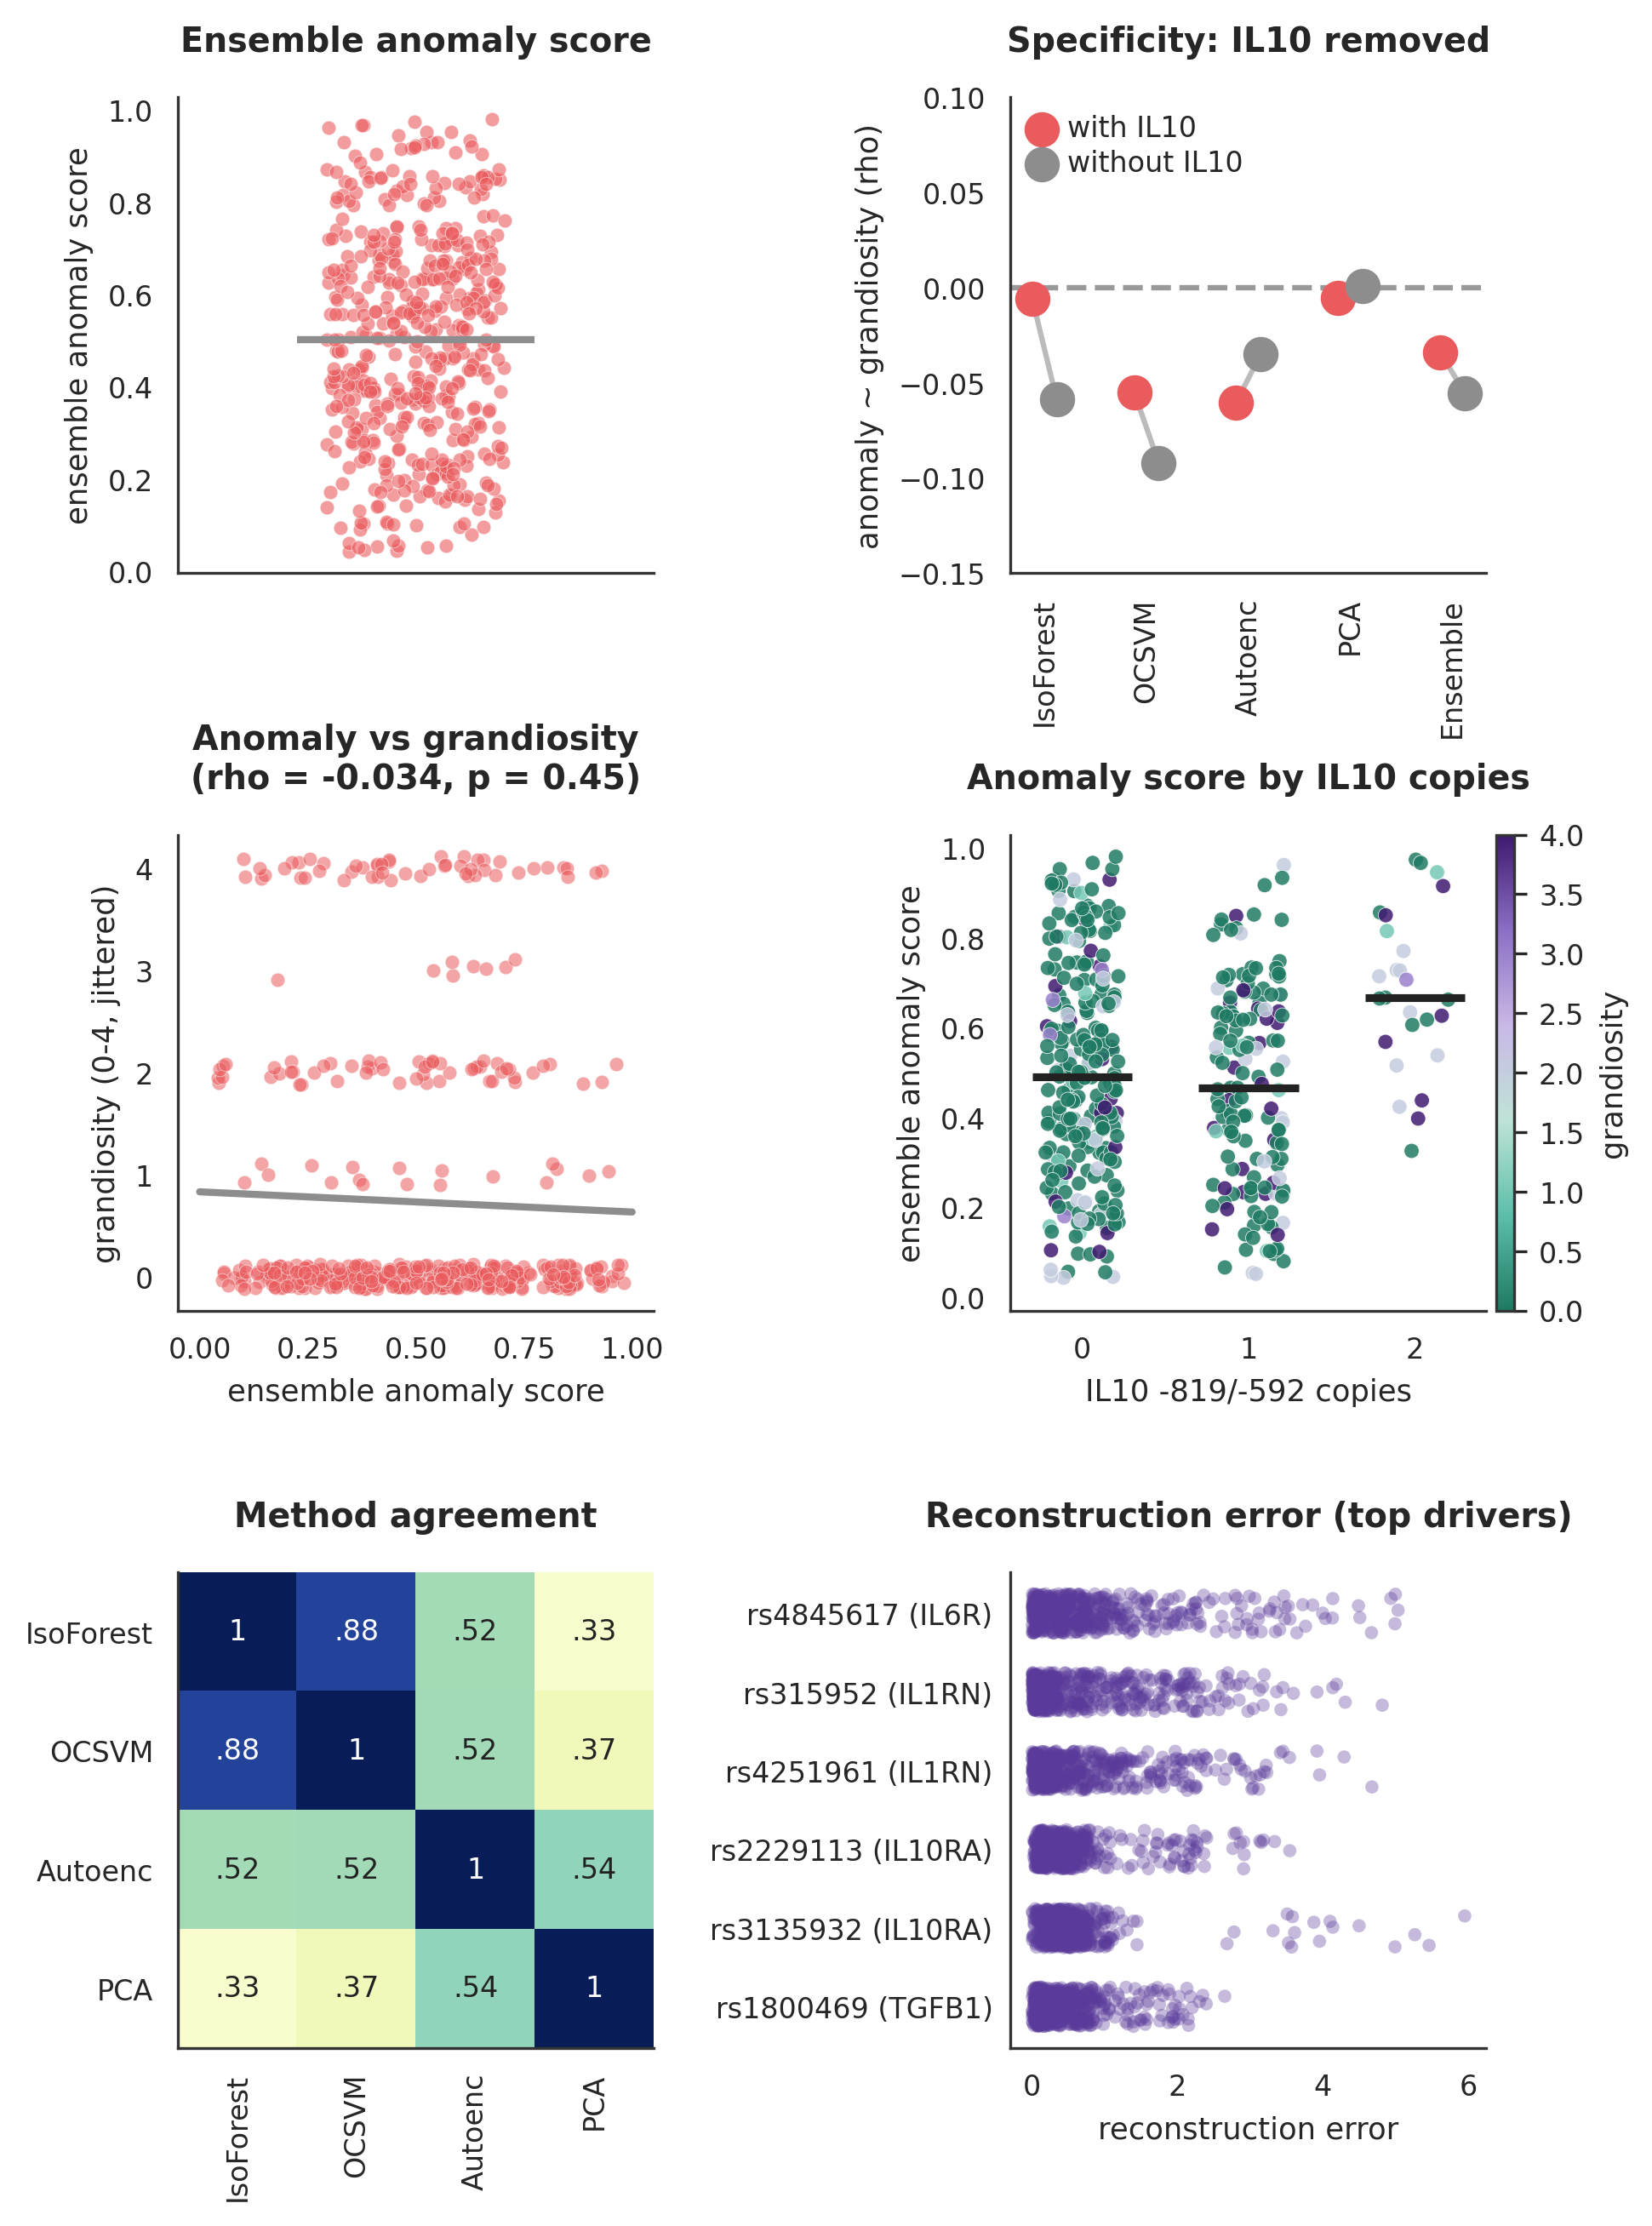

In [14]:
plt.rcParams.update(FIG_RC)
TEALPURP = LinearSegmentedColormap.from_list("tp", ["#1f7a63","#5DBFA9","#bfe3d8","#c9b8e6","#8b6fc4","#3f1a70"])
fig, _A = plt.subplots(3, 2, figsize=(6.10, 8.68)); rng = np.random.default_rng(3)
AX = np.empty((2, 3), dtype=object)
for _k, (_i, _j) in enumerate([(0,0),(0,1),(0,2),(1,0),(1,1),(1,2)]):
    AX[_i, _j] = _A[_k // 2, _k % 2]
a = AX[0,0]; a.scatter(rng.uniform(-0.3,0.3,len(ensemble)), ensemble, s=16, color=CORAL, alpha=.6, edgecolor="white", linewidth=.2); a.hlines(np.median(ensemble), -0.4, 0.4, color=GREY, lw=2)
a.set_xlim(-0.8,0.8); a.set_xticks([]); a.set_ylabel("ensemble anomaly score"); a.set_title("Ensemble anomaly score")
a = AX[0,1]; ks = list(spec); xs_ = np.arange(len(ks))
for i,k in enumerate(ks):
    a.plot([i-0.12, i+0.12], [spec[k][0], spec[k][1]], color="#bbb", lw=1.5, zorder=1)
    a.scatter(i-0.12, spec[k][0], color=CORAL, s=80, zorder=3, label="with IL10" if i==0 else None); a.scatter(i+0.12, spec[k][1], color=GREY, s=80, zorder=3, label="without IL10" if i==0 else None)
a.axhline(0, ls="--", color="#999"); a.set_xticks(xs_); a.set_xticklabels(ks, rotation=90, ha="center", va="top"); a.set_ylim(-0.15, 0.10); a.set_ylabel("anomaly ~ grandiosity (rho)"); a.set_title("Specificity: IL10 removed"); a.legend(loc="upper left", frameon=False, handlelength=1.0, handletextpad=0.4, labelspacing=0.25, borderaxespad=0.2)
a = AX[0,2]; a.scatter(ensemble, gr_ad + rng.uniform(-0.12,0.12,len(gr_ad)), s=16, color=CORAL, alpha=.55, edgecolor="white", linewidth=.2)
sl, ic = np.polyfit(ensemble, gr_ad, 1); xx = np.linspace(0,1,10); a.plot(xx, sl*xx+ic, color=GREY, lw=2)
a.set_xlabel("ensemble anomaly score"); a.set_ylabel("grandiosity (0-4, jittered)"); a.set_yticks(range(5)); a.set_title(f"Anomaly vs grandiosity\n(rho = {rho_e:.3f}, p = {p_e:.2f})")
a = AX[1,0]
for c in [0,1,2]:
    s = okc2 & (il10_ad==c); n_ = int(s.sum()); a.scatter(c + rng.uniform(-0.22,0.22,n_), ensemble[s], c=gr_ad[s], cmap=TEALPURP, vmin=0, vmax=4, s=18, alpha=.85, edgecolor="white", linewidth=.2)
    a.hlines(np.median(ensemble[s]), c-0.3, c+0.3, color="#222", lw=2.2, zorder=5)
a.set_xticks([0,1,2]); a.set_ylim(-0.03, 1.03); a.set_xlabel("IL10 -819/-592 copies"); a.set_ylabel("ensemble anomaly score"); a.set_title("Anomaly score by IL10 copies")
sm_ = ScalarMappable(norm=Normalize(0,4), cmap=TEALPURP); sm_.set_array([]); fig.colorbar(sm_, cax=a.inset_axes([1.02, 0.0, 0.038, 1.0]), label="grandiosity")
a = AX[1,1]; im = a.imshow(agree.values, cmap="YlGnBu", vmin=0.3, vmax=1, aspect="auto"); a.set_xticks(range(4)); a.set_yticks(range(4)); a.set_xticklabels(names, rotation=90, ha="center", va="top"); a.set_yticklabels(names)
for i in range(4):
    for j in range(4): a.text(j, i, ("1" if agree.values[i,j] >= 0.999 else f"{agree.values[i,j]:.2f}".lstrip("0")), ha="center", va="center", color="white" if agree.values[i,j] > 0.65 else "#222", fontsize=8)
a.set_title("Method agreement")  # every cell is annotated, so no colour bar is needed
a = AX[1,2]; top6 = drivers.head(6).index[::-1]
for i, m in enumerate(top6):
    j = markers.index(m); a.scatter(pm[:, j], i + rng.uniform(-0.25,0.25,len(pm)), s=14, color="#5a3a9a", alpha=.35, edgecolor="none")
a.set_yticks(range(len(top6))); a.set_yticklabels([f"{m} ({gene_of[m]})" for m in top6]); a.tick_params(axis="y", pad=1.5); a.set_xlabel("reconstruction error"); a.set_title("Reconstruction error (top drivers)")
for r_ in AX:
    for a in r_: sns.despine(ax=a)
fig.subplots_adjust(left=0.13, right=0.97, top=0.96, bottom=0.08, wspace=0.75, hspace=0.55); save_tiff(fig, "Figure3_anomaly.tif"); plt.show()


## S10. Manifest

In [15]:
import json
MANIFEST["analysis_N"] = {"value": int(N), "decimals": None}
json.dump(MANIFEST, open("revision_manifest.json","w"), indent=1, default=float)
print(len(MANIFEST), "keys written to revision_manifest.json")
for k,v in MANIFEST.items(): print(f"{k:45s} {v['value']}")

156 keys written to revision_manifest.json
S1_min_call_rate_pct                          93.46938775510205
S1_n_hwe_fail_cases                           0.0
S1_n_hwe_fail_controls                        0.0
S1_min_allelic_q                              0.551
S1_rs1800871_MAF_cases                        0.226
S1_rs1800871_MAF_controls                     0.25
S1_rs1800871_HWE_cases                        0.586
S1_rs1800871_HWE_controls                     0.203
S1_rs1800871_allelic_p                        0.2049
S1_rs1800872_MAF_cases                        0.225
S1_rs1800872_MAF_controls                     0.25
S1_rs1800872_HWE_cases                        0.447
S1_rs1800872_HWE_controls                     0.193
S1_rs1800872_allelic_p                        0.2003
S2_n_pairs_r2_over_0.8                        8.0
S2_max_r2_nonIL10                             1.0
S2_TGFB1_r2                                   0.764
S2_IL10_tags_r2                               0.988
S3_IL10_p_unweigh

## Verification

Each value quoted in the manuscript is checked against the value printed in the paper. The cell raises if any of them disagree.


In [16]:
# ---- verification against the published values ----
# revision_manifest.json holds every value quoted in the revision. The keys below
# are the ones that appear in the manuscript text; each is checked against the
# printed value so that a run which fails to reproduce the analysis fails loudly.
_manifest = {k: (v["value"] if isinstance(v, dict) else v)
             for k, v in json.load(open("revision_manifest.json")).items()}

published = {
    "S3_IL10_p_unweighted":      (0.0028,   5e-5),
    "S3_IL10_q_unweighted":      (0.023,    5e-4),
    "S3_IL10_p_beta125":         (0.0003,   5e-5),
    "S3_IL10_p_pruned":          (0.0052,   5e-5),
    "S3_IL10_p_standardised":    (0.0012,   5e-5),
    "S4_n_score_0":              (356,      0),
    "S4_n_score_4":              (51,       0),
    "S4_pct_any":                (27.2,     0.05),
    "S4_n_item57_positive":      (110,      0),
    "S5_n_two_copy":             (26,       0),
    "S5_n_two_copy_grandiose":   (17,       0),
    "S5_ols_beta_rint":          (0.58,     0.005),
    "S5_cliff_delta":            (0.39,     0.005),
    "S5_fragility_index":        (6,        0),
    "S5_OR_at_fragility":        (2.11,     0.005),
    "S5_lko1_OR_min":            (4.93,     0.005),
    "S5_lko1_OR_max":            (5.96,     0.005),
}
_failed = [(k, _manifest[k], v) for k, (v, tol) in published.items()
           if k not in _manifest or abs(_manifest[k] - v) > tol]
if _failed:
    for k, got, want in _failed:
        print(f"  MISMATCH {k}: this run {got!r}, manuscript {want!r}")
    raise AssertionError(f"{len(_failed)} result(s) do not match the published values")
print(f"All {len(published)} checked results match the published values.")
print(f"revision_manifest.json holds {len(_manifest)} recorded values in total.")


All 17 checked results match the published values.
revision_manifest.json holds 156 recorded values in total.
